# Assignment 5: Data Visualization
```
Course: ENV 700 - Environmental Data Exploration
Author: Student Name
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Visualization**, the third/fourth stage in the data analytics pipeline: **exploration, wrangling, analysis, and visualization**.

In this notebook, you will be working with two datasets: the Peter/Paul Northern Lakes Chemistry & Nutrients processed dataset, and the NEON Niwot Litter Mass Trap dataset. Specifically, we will be visualizing various aspects and relationships among the variable in these datasets. 

As always, address the tasks below to the best of your ability. Be sure to ask if any question is ambigious or unclear. When complete. Export your notebook into an HTML formatted document. Also, stage, commit, and push your assignment to your GitHub repository. 

#### 1. Setup
* 1.1 Import the Path, Pandas, Seaborn, and Calendar packages into your notebook
* 1.2 Set path objects for your project folder, the raw data folder, and the `Processed_Key` folder

In [2]:
# 1.1 Packages
import pandas as pd
import seaborn as sns 
from pathlib import Path
import calendar

In [8]:
# 1.2 Paths 
root_fldr = Path.cwd().parent
raw_fldr = root_fldr / 'data' / 'raw'
processed_fldr = root_fldr / 'data'/ 'Processed_KEY'

#### 2. Ingest Data & Wrangle
* 2.1 NTL LTER data for Peter and Paul Lakes
    - Read the `'NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv'` file into a dataframe. 
    - Convert the `sampledate` column to a datetime object.
    - Create a `month_abb` column to be an ordered categorical data type with levels for all months.
    - Display the first 5 records of the dataframe
* 2.2 NEON NIWO Litter Mass Trap Data (processed)
    - Read in the `NEON_NIWO_Litter_mass_trap_Processed.csv` file into a dataframe.
    - Convert the `collectDate` column to a datatime object.
    - Create a `year` column from the `collectDate` column 
    - Display the first 5 records of the dataframe

In [34]:
# 2.1.1 Import the NTL_LTER dataset as a dataframe, converting the sampledate field to a datetime object
NTL_LTER = (
    pd.read_csv(
    processed_fldr/'NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv',
    parse_dates=['sampledate']
    )
    .assign(
        month = lambda df:df ['sampledate'].dt.month,
        year = lambda df: df['sampledate'].dt.year,
        month_ab = lambda df:df ['sampledate'].dt.month_name().str[:3]
    )
  .astype({
        'month_ab':'category'
    })
)

#NTL_LTER.sample(10,random_state=42)
NTL_LTER.head()

,lakename,year4,daynum,month,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,tn_ug,tp_ug,nh34,no23,po4,year,month_ab
0,Paul Lake,1984,148,5,1984-05-27,0.00,14.5,9.5,1750.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
1,Paul Lake,1984,148,5,1984-05-27,0.25,NaN,NaN,1550.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
2,Paul Lake,1984,148,5,1984-05-27,0.50,NaN,NaN,1150.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
3,Paul Lake,1984,148,5,1984-05-27,0.75,NaN,NaN,975.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
4,Paul Lake,1984,148,5,1984-05-27,1.00,14.5,8.8,870.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May


In [31]:
NEON_NIWO = (
    pd.read_csv(
        processed_fldr/'NEON_NIWO_Litter_mass_trap_Processed.csv',
        parse_dates=['collectDate']
    )
    .rename(columns={
        'collectDate': 'collect_date' #like syntax more for the future usage in the lab 
    })
    .assign(
        month = lambda df:df ['collect_date'].dt.month,
        year = lambda df: df['collect_date'].dt.year,
        month_ab = lambda df:df ['collect_date'].dt.month_name().str[:3]
    )
    .astype({
        'month_ab':'category'
    })
)

#NEON_NIWO.sample(10,random_state=42)
NEON_NIWO.info()

<class 'pandas.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   plotID            1692 non-null   str           
 1   trapID            1692 non-null   str           
 2   collect_date      1692 non-null   datetime64[us]
 3   functionalGroup   1692 non-null   str           
 4   dryMass           1692 non-null   float64       
 5   qaDryMass         1692 non-null   str           
 6   subplotID         1692 non-null   int64         
 7   decimalLatitude   1692 non-null   float64       
 8   decimalLongitude  1692 non-null   float64       
 9   elevation         1692 non-null   float64       
 10  nlcdClass         1692 non-null   str           
 11  plotType          1692 non-null   str           
 12  geodeticDatum     1692 non-null   str           
 13  month             1692 non-null   int32         
 14  year              1692 non-null   i

In [ ]:
# 2.1.2 Create a month column to be an ordered categorical data type with levels for all months.

# did in main above in 1 code chunk 

In [46]:
# 2.1.3 Display the first 5 records of the dataframe
NTL_LTER.head()


,lakename,year4,daynum,month,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,tn_ug,tp_ug,nh34,no23,po4,year,month_ab
14906,Peter Lake,2006,219,8,2006-08-07,4.5,12.9,9.1,7.7,303.0,NaN,NaN,NaN,NaN,NaN,2006,Aug
3472,Peter Lake,1988,180,6,1988-06-28,6.5,8.1,13.0,0.6,46.0,NaN,NaN,NaN,NaN,NaN,1988,Jun
12310,Paul Lake,2002,191,7,2002-07-10,5.5,6.9,0.6,4.2,802.5,NaN,NaN,NaN,NaN,NaN,2002,Jul
9093,Paul Lake,1996,204,7,1996-07-22,0.5,22.1,7.8,1020.0,1009.0,NaN,NaN,NaN,NaN,NaN,1996,Jul
14070,Peter Lake,2005,185,7,2005-07-04,4.5,10.7,12.0,22.5,1201.0,NaN,NaN,NaN,NaN,NaN,2005,Jul
2797,Paul Lake,1987,228,8,1987-08-16,6.0,7.8,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1987,Aug
4191,Paul Lake,1989,184,7,1989-07-03,0.0,23.9,6.7,510.0,370.0,NaN,NaN,NaN,NaN,NaN,1989,Jul
22673,Peter Lake,2013,148,5,2013-05-28,0.5,NaN,NaN,NaN,NaN,368.44899,3.49961,NaN,NaN,NaN,2013,May
17336,Peter Lake,2010,172,6,2010-06-21,2.5,19.5,9.2,154.0,1144.0,NaN,NaN,NaN,NaN,NaN,2010,Jun
1383,Paul Lake,1986,181,6,1986-06-30,2.0,21.2,7.3,290.0,NaN,NaN,NaN,NaN,NaN,NaN,1986,Jun


In [ ]:
# 2.2.1 Import the NEON NIWO dataset, setting the `collectDate` field to a datetime object
# did in main above in 1 code chunk 

In [ ]:
# 2.2.2 Create a year column from the `collectDate` field.
#done in main code above in 1 code chunk

In [38]:
# 2.2.3 Display the first 5 records of the dataframe

NEON_NIWO.head()


,plotID,trapID,collect_date,functionalGroup,dryMass,qaDryMass,subplotID,decimalLatitude,decimalLongitude,elevation,nlcdClass,plotType,geodeticDatum,month,year,month_ab
0,NIWO_062,NIWO_062_050,2016-06-16,Seeds,0.00,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84,6,2016,Jun
1,NIWO_061,NIWO_061_169,2016-06-16,Other,0.27,N,41,40.047615,-105.586103,3413.4,evergreenForest,tower,WGS84,6,2016,Jun
2,NIWO_062,NIWO_062_050,2016-06-16,Woody material,0.12,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84,6,2016,Jun
3,NIWO_064,NIWO_064_103,2016-06-16,Seeds,0.00,N,32,40.047370,-105.583997,3373.2,evergreenForest,tower,WGS84,6,2016,Jun
4,NIWO_058,NIWO_058_101,2016-06-16,Needles,1.11,Y,32,40.048719,-105.587181,3446.4,shrubScrub,tower,WGS84,6,2016,Jun


#### 3. Set your Seaborn Theme
* Choose a Seaborn theme; set its context to what you feel is appropriate for this notebook
* Set its palette to be colorblind friendly and set the font scale to 0.8 (Hint: See <https://seaborn.pydata.org/generated/seaborn.set_theme.html>)
* Set the theme's runtime configuration (`rc`) so that plots have a *title size* of 20 and use a serif *font family*.

In [45]:
#3. Set the seaborn theme
sns.set_theme(
    style='darkgrid',
    context= 'notebook',
    font_scale= .8,
    palette='colorblind',
    rc={
        'font.family': 'serif',
        'figure.titlesize': 20
    }
)

In [55]:
NTL_LTER.head()

,lakename,year4,daynum,month,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,tn_ug,tp_ug,nh34,no23,po4,year,month_ab
0,Paul Lake,1984,148,5,1984-05-27,0.00,14.5,9.5,1750.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
1,Paul Lake,1984,148,5,1984-05-27,0.25,NaN,NaN,1550.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
2,Paul Lake,1984,148,5,1984-05-27,0.50,NaN,NaN,1150.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
3,Paul Lake,1984,148,5,1984-05-27,0.75,NaN,NaN,975.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
4,Paul Lake,1984,148,5,1984-05-27,1.00,14.5,8.8,870.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May


#### 4. Relationship of Total Phosphorous to Phosphate
Total Phosphorus (TP) measures every form of phosphorus in a lake, while phosphate (orthophosphate or PO₄) is the specific, dissolved, inorganic fraction that algae can directly absorb. We might therefore expect PO₄ to increase with increases in TP; we want to confirm that expectation with a visualization of our data. 
- Create a scatterplot of PO₄ as a function of TP (assign TP to the x-axis), using separate aesthetics to differientiate the two (Peter and Paul) lakes.
- Adjust your axes to hide extreme values. (Hint: change the limits using `xlim()` and `ylim()`).
- If your plot as many overlapping points, consider making the point features semi-transparent.
- Ensure your plot has an appropriate title, axis labels, and other stylistic features to make it look tidy and professional. 

[Text(0.5, 1.0, 'Phosphorous Concentration Over Time'),
 Text(0.5, 0, ''),
 Text(0, 0.5, ''),
 (0.0, 60.0)]

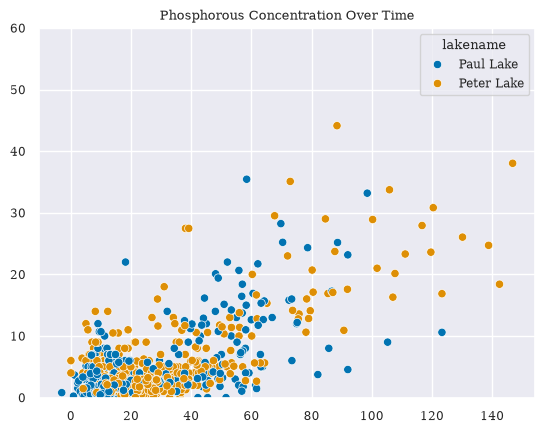

In [65]:
# 4. Create a scatterplot of PO4 vs TP
g = sns.scatterplot (
    data=NTL_LTER,
    x='tp_ug',
    y='po4',
    hue='lakename',
)

g.set(
    title = 'Phosphorous Concentration Over Time',
    xlabel = '',
    ylabel = '',
    ylim = (0,60)
)

#### 4-Challenge
* Re-construct your plot so that it includes a regression line (hint: `lmplot()`)
* Note that for the regression line to exclude extreme values, you'll have to filter the dataframe used in the plot; setting the x and y limits won't do that for you. 

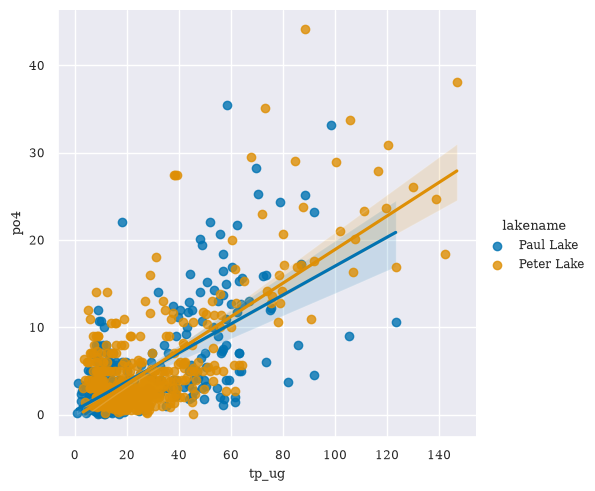

In [69]:
# 4-challenge

g = sns.lmplot(
    data=NTL_LTER.loc[
        (NTL_LTER['po4'] <60) &
        (NTL_LTER['po4'] >0) &
        (NTL_LTER['tp_ug'] >0) 
    ],
    x='tp_ug',
    y='po4',
    hue='lakename',
)


### 5. Comparison of monthly trends of select variables across lakes
We are interested in comparing monthly trends in three lake variables: Total Nitrogren, Total Phosphorus, and Temperature, contrasting differences among the two lakes.
* 5.1 First, you'll need to "melt" your data so that all temperature, TP, and TN measures appear in a single column alongside a separate column that lists whether the row is temperature, TN, or TP record.
* 5.2 Construct a box plot of the 3 lake measurements such that
    - Months appear along the x-axis
    - Peter and Paul lake data are shown in different colors
    - The plots for temperature, TN, and TP are shown as separate facets, stacked vertically, and each have their own y-axis scale (hint: `sharey=False`).
    - Remove the individual plot titles and x-axis labels (hint: set to an empty string `""`).
    - Set the y-axis labels to indicate the plots of Temperature, Total Nitrogen, and Total Phosphorus. 

In [70]:
NTL_LTER.head()

,lakename,year4,daynum,month,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,tn_ug,tp_ug,nh34,no23,po4,year,month_ab
0,Paul Lake,1984,148,5,1984-05-27,0.00,14.5,9.5,1750.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
1,Paul Lake,1984,148,5,1984-05-27,0.25,NaN,NaN,1550.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
2,Paul Lake,1984,148,5,1984-05-27,0.50,NaN,NaN,1150.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
3,Paul Lake,1984,148,5,1984-05-27,0.75,NaN,NaN,975.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May
4,Paul Lake,1984,148,5,1984-05-27,1.00,14.5,8.8,870.0,1620.0,NaN,NaN,NaN,NaN,NaN,1984,May


In [ ]:
# 5.1 Melt the NTL LTR dataset so that Temperature, TN, and TP measures are consolidated in a single column

NTL_LTER_long = NTL_LTER.melt(
    id_vars=['lakename','month_ab'],
    value_vars=['tn_ug','tp_ug','temperature_C'],
    var_name='measurement_type',
    value_name='measurement_value'
)



In [83]:
NTL_LTER_long.head(5)

,lakename,month_ab,measurement_type,measurement_value
0,Paul Lake,May,tn_ug,NaN
1,Paul Lake,May,tn_ug,NaN
2,Paul Lake,May,tn_ug,NaN
3,Paul Lake,May,tn_ug,NaN
4,Paul Lake,May,tn_ug,NaN


Text(0.5, 0.98, 'Average Daily Dry Mass by NLCD Class (2016 - 2019)')

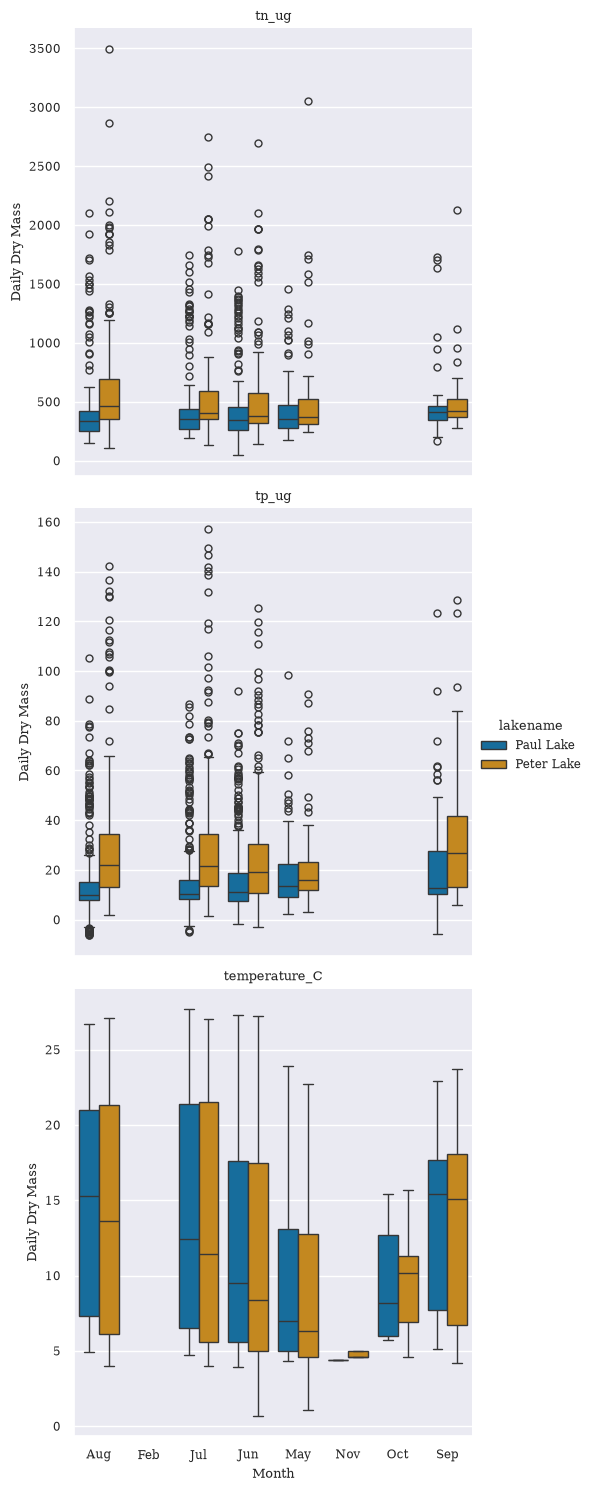

In [231]:
# 5.2 Create the faceted plot
melt_plot = sns.catplot(
    data=NTL_LTER_long,
    x='month_ab',
    y='measurement_value',
    hue='lakename',
    kind='box',
    col='measurement_type',
    col_wrap=1,
    sharey=False
)

# 5.3 Style the plot
melt_plot.set(xlabel='')

melt_plot.set(
    xlabel='Month',
    ylabel='Daily Dry Mass',
)

melt_plot.set_titles('{col_name}')

g.fig.suptitle('Average Daily Dry Mass by NLCD Class (2016 - 2019)') 


#### ✅ Question
**What do you observe about the variables of interest over seasons and between lakes?**
> **Answer**: There seems to be a greater variability in values for Peter given the wider boxes entailing there's a wider spread of data in tp_ug and  tn_ug. Also would be curious to see how this variance may have differed over time. 
>  

### 6. Dry mass of needles over time
We are curious how the amount of needles is changing from year to year, specifically how those trends might appear across different land cover types. To do that we'll explore a few visualizations. 

#### 6.1 Change in needle dry mass over time, single plot
* Plot a subset of the litter dataset by displaying only the "Needles" functional group in a single plot figure. 
* Plot the dry mass of needle litter by year, separating by NLCD class with a color aesthetic. (no need to adjust the name of each land use)
* Treat the years as categorical data in your selection of `displot()`, `catplot()`, or `relplot()` plotting functions. 
* Select a plotting function subplot type (e.g. "scatterplot" for relplot, "swarmplot" for catplot) that you feel best illustrates change over time of the needle dry mass from year to year to year for the different land cover types.
* Style your plot for professionalism and clarity.  Specifically:
    - Give your plot a title.
    - Label axes appropriately. ("Year" is an optional label, as it can be considered obvious.)
    - Title and place your legend to maximize clarity.
    - Ensure that your font sizes are appropriate. (Hint: adjust plot height and aspect.)
    - *You can use default cover type names, e.g. `shrubScrub`.*

In [97]:
NEON_NIWO.head()

,plotID,trapID,collect_date,functionalGroup,dryMass,qaDryMass,subplotID,decimalLatitude,decimalLongitude,elevation,nlcdClass,plotType,geodeticDatum,month,year,month_ab
0,NIWO_062,NIWO_062_050,2016-06-16,Seeds,0.00,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84,6,2016,Jun
1,NIWO_061,NIWO_061_169,2016-06-16,Other,0.27,N,41,40.047615,-105.586103,3413.4,evergreenForest,tower,WGS84,6,2016,Jun
2,NIWO_062,NIWO_062_050,2016-06-16,Woody material,0.12,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84,6,2016,Jun
3,NIWO_064,NIWO_064_103,2016-06-16,Seeds,0.00,N,32,40.047370,-105.583997,3373.2,evergreenForest,tower,WGS84,6,2016,Jun
4,NIWO_058,NIWO_058_101,2016-06-16,Needles,1.11,Y,32,40.048719,-105.587181,3446.4,shrubScrub,tower,WGS84,6,2016,Jun


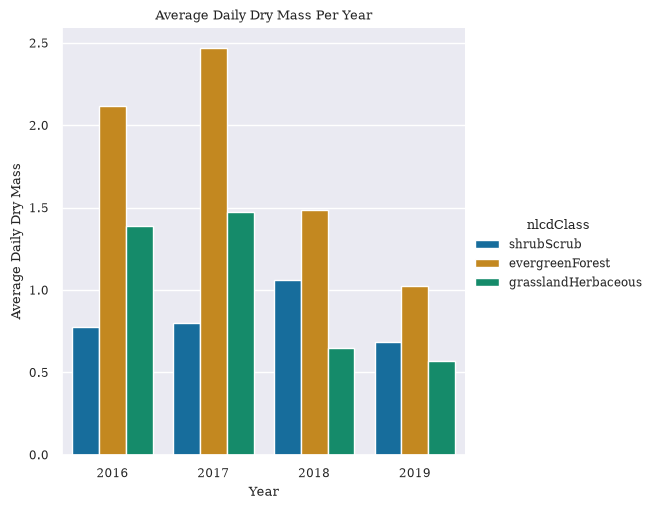

In [176]:
# 6. Plot the dry mass of needles over time, separated by NLCD cover type
g = sns.catplot(
    data = NEON_NIWO,
    x='year',
    y='dryMass',
    hue='nlcdClass',
    #log_scale= True,
    kind='bar',
    errorbar= None
)

g.set(
    title = 'Average Daily Dry Mass Per Year',
    xlabel='Year',
    ylabel='Average Daily Dry Mass'
)

#### 6.2 Change in needle dry mass over time, facet plot
* Recreate your plot above, but instead of a single plot, break your plot into 3 facets: one for each cover type. 
* You are welcome to explore different plot subtypes than the previous plot. 
* Decide whether you want to stack the facet plots vertically or horizontally based on how well it communicates differences in the trends and magnitude of leaf litter change over time across the different cover types. 
* As before, style your plot for professionalism and clarity. 

In [217]:
NEON_NIWO.info(0)

<class 'pandas.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   plotID            1692 non-null   str           
 1   trapID            1692 non-null   str           
 2   collect_date      1692 non-null   datetime64[us]
 3   functionalGroup   1692 non-null   str           
 4   dryMass           1692 non-null   float64       
 5   qaDryMass         1692 non-null   str           
 6   subplotID         1692 non-null   int64         
 7   decimalLatitude   1692 non-null   float64       
 8   decimalLongitude  1692 non-null   float64       
 9   elevation         1692 non-null   float64       
 10  nlcdClass         1692 non-null   str           
 11  plotType          1692 non-null   str           
 12  geodeticDatum     1692 non-null   str           
 13  month             1692 non-null   int32         
 14  year              1692 non-null   i

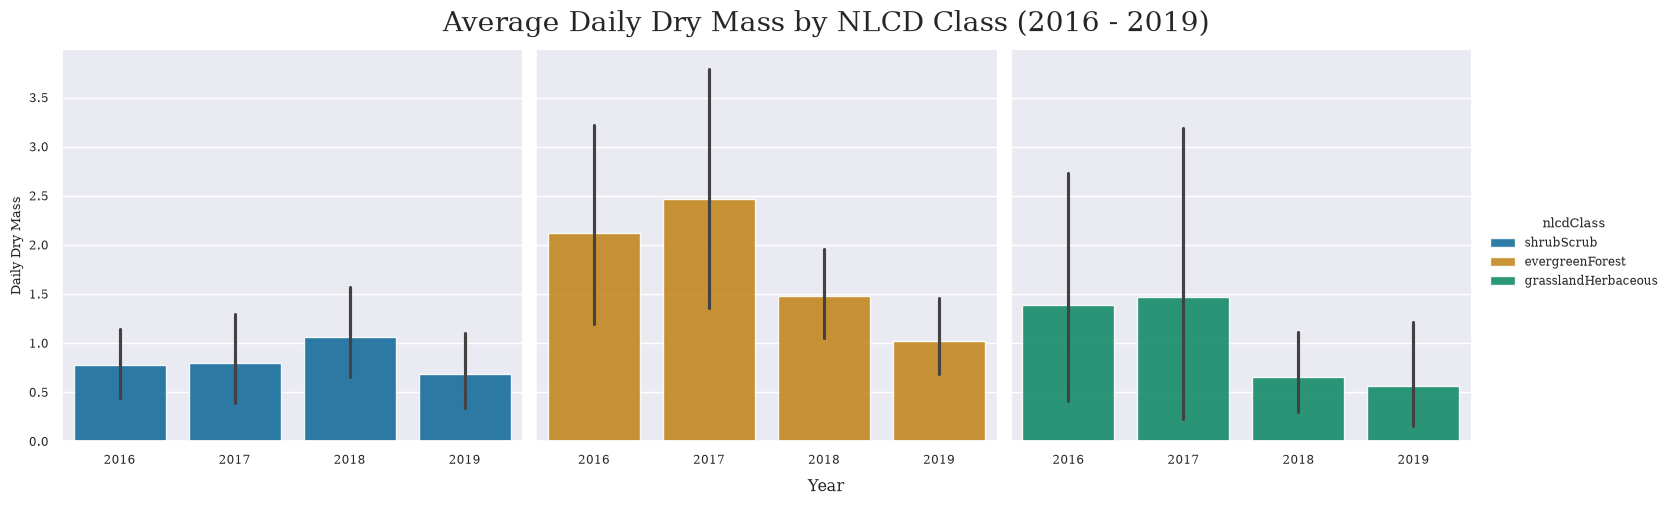

In [237]:
# 6.2 Plot the dry mass of needles over time, faceted by NLCD cover type

g = sns.catplot(
    data = NEON_NIWO,
    x='year',
    y='dryMass',
    col='nlcdClass',
    hue='nlcdClass',
    col_wrap=3,
    alpha = .9,
    kind='bar',
    palette='colorblind',
    #errorbar=None,
    #aspect=2
)

#g.tight_layout()

g.set(
    title='',
    xlabel='',
    ylabel='Daily Dry Mass',
)

g.fig.supxlabel('Year')
g.fig.suptitle('Average Daily Dry Mass by NLCD Class (2016 - 2019)') 


g.fig.subplots_adjust(top=.9) #I used AI to help teach me how to have more space between the top header and the graphs 

#### ✅ Question
**Which of the two plots do you feel better reveals the pattern of needle dry mass over time? Why?**
> **Answer**:  
>  I think the 2nd graph with the parts broken up is clearer for me to see the trends as it's clear that there is a downward trend in 2018 and 2019 across categories, but can seperate that out more clearly based off of each category. 


#### ✅ Question
**Explain your choice of subplot in the plots above. What aspects of that subplot type led to your choice.**
> **Answer**:  
>  I thought that the bar graph provided the clearest depiction of each data set. When I was trying violin and box plots, the data was too condensed near 0 as there wasn't enough spread of the datapoints thus inhibiting analsysis graphically. 

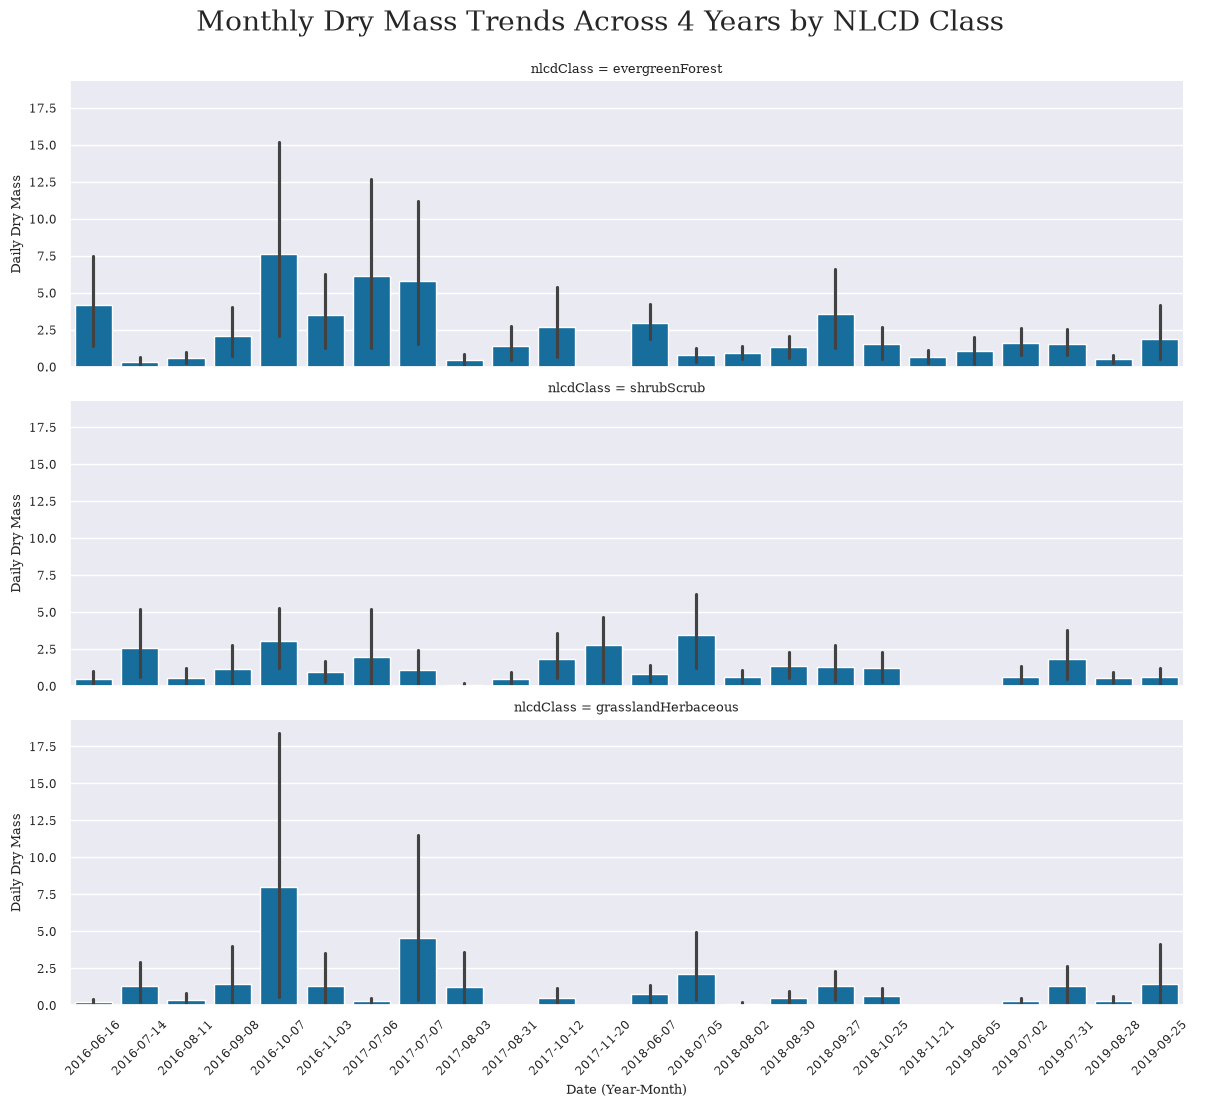

In [216]:
# playing around with cluade to see how I could see the full data borken down per month 

g = sns.catplot(
    data = NEON_NIWO.loc[NEON_NIWO['dryMass']>0],
    x='collect_date',
    y='dryMass',
    col='nlcdClass',
    col_wrap=1,
    kind='bar',
    #palette='colorblind',
    height=4,
    aspect=3  # Make it wider to fit all 48 months
)

g.set(
    xlabel='Date (Year-Month)',
    ylabel='Daily Dry Mass',
)

g.fig.suptitle('Monthly Dry Mass Trends Across 4 Years by NLCD Class')

# Rotate x-axis labels for readability
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    
g.fig.subplots_adjust(top=0.92, bottom=0.15)
